In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, Flatten, MaxPooling2D, Rescaling
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
dataset_dir = '/content/drive/MyDrive/Test'

In [ ]:
batch_size = 64
img_height = 900
img_width = 600

In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size)

Found 350 files belonging to 7 classes.
Using 280 files for training.
Found 350 files belonging to 7 classes.
Using 70 files for validation.


In [ ]:
class_names = train_ds.class_names
class_names

['Basil', 'Chinar', 'Guava', 'Jamun', 'Jatropha', 'Lemon', 'Mango']

In [ ]:
model = Sequential([
    Rescaling(1./255.0, input_shape=(img_height, img_width, 3)),
    Conv2D(12, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(4, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(4, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(16, activation='relu'),
    Dense(32, activation='relu'),
    Dense(64, activation='relu'),
    Dense(len(class_names), activation='softmax')
])

In [ ]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [ ]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling_1 (Rescaling)     (None, 900, 600, 3)       0         
                                                                 
 conv2d_3 (Conv2D)           (None, 898, 598, 12)      336       
                                                                 
 max_pooling2d_3 (MaxPoolin  (None, 449, 299, 12)      0         
 g2D)                                                            
                                                                 
 conv2d_4 (Conv2D)           (None, 447, 297, 4)       436       
                                                                 
 max_pooling2d_4 (MaxPoolin  (None, 223, 148, 4)       0         
 g2D)                                                            
                                                                 
 conv2d_5 (Conv2D)           (None, 221, 146, 4)      

In [ ]:
epochs = 15
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)

Epoch 1/15
5/5 [==============================] - 6s 625ms/step - loss: 0.9873 - accuracy: 0.6000 - val_loss: 1.9632 - val_accuracy: 0.4429
Epoch 2/15
5/5 [==============================] - 6s 672ms/step - loss: 0.9809 - accuracy: 0.6536 - val_loss: 1.8631 - val_accuracy: 0.3429
Epoch 3/15


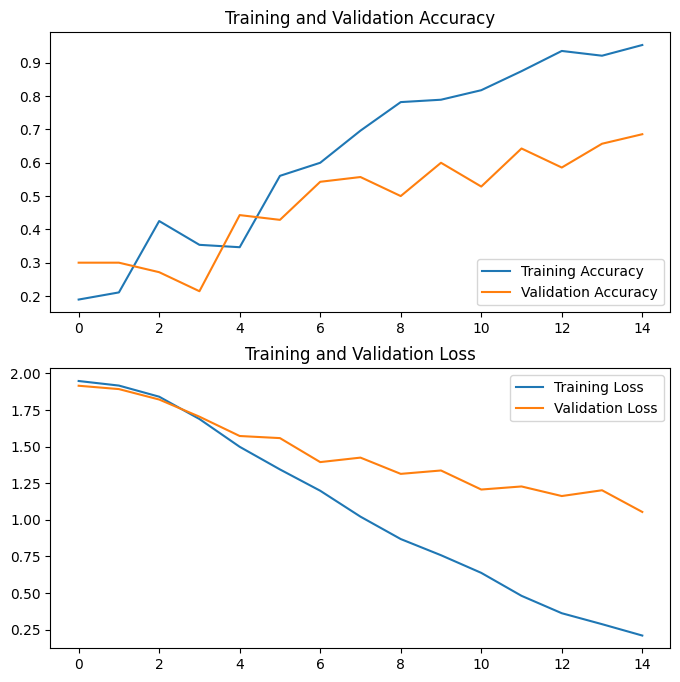

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(range(epochs), acc, label='Training Accuracy')
plt.plot(range(epochs), val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(range(epochs), loss, label='Training Loss')
plt.plot(range(epochs), val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [ ]:
test_loss, test_acc = model.evaluate(val_ds)
print('Test Loss:', test_loss)
print('Test Accuracy:', test_acc)

2/2 [==============================] - 1s 27ms/step - loss: 1.0099 - accuracy: 0.4571
Test Loss: 1.0099011659622192
Test Accuracy: 0.4571428596973419


In [ ]:
# Display the maximum validation accuracy
print("Maximum Validation Accuracy:", max(val_acc))

Maximum Validation Accuracy: 0.5


In [ ]:
print("Minimum Validation Loss:", min(val_loss))

Minimum Validation Loss: 1.0099011659622192


In [ ]:
import numpy as np

# Command for importing image from web
# sunflower_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/592px-Red_sunflower.jpg"
# sunflower_path = tf.keras.utils.get_file('Red_sunflower', origin=sunflower_url)

# img = tf.keras.utils.load_img(sunflower_path, target_size=(img_height, img_width))


testing_image = '/content/drive/MyDrive/Leaves/Lemon/compressed_0010_0013.JPG'

img = tf.keras.utils.load_img(
    testing_image, target_size=(img_height, img_width)
)

img_array = tf.keras.utils.img_to_array(img)
img_array = tf.expand_dims(img_array, axis=0) # Create a batch

predictions = model.predict(img_array)
score = tf.nn.softmax(predictions[0])

print("-"*200)

print(class_names)
print("Score: ", score)

print("-"*200)

print(
    "This image most likely belongs to {} with a {:.2f} percent confidence."
    .format(class_names[np.argmax(score)], 100 * np.max(score))
)


1/1 [==============================] - 0s 293ms/step
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
['Basil', 'Chinar', 'Guava', 'Jamun', 'Jatropha', 'Lemon', 'Mango']
Score:  tf.Tensor(
[0.13182461 0.11971822 0.12237807 0.12005623 0.1217743  0.26454493
 0.11970362], shape=(7,), dtype=float32)
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
This image most likely belongs to Lemon with a 26.45 percent confidence.
